# Importing packages

In [1]:
import pandas as pd 
import numpy as np
from keras.models import Sequential
from keras.layers import Activation,Dense,Dropout
from keras.preprocessing.text import Tokenizer
from sklearn.preprocessing import LabelBinarizer
import sklearn.datasets as skds

In [2]:
df = pd.read_csv('BBCTextData/bbc-text.csv')
df.head(10)

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...
5,politics,howard hits back at mongrel jibe michael howar...
6,politics,blair prepares to name poll date tony blair is...
7,sport,henman hopes ended in dubai third seed tim hen...
8,sport,wilkinson fit to face edinburgh england captai...
9,entertainment,last star wars not for children the sixth an...


# Train Test Split

In [85]:
total_data_size = len(df)
total_data_size

2225

In [86]:
train_data_size = int(total_data_size * 0.8)
test_data_size = int(total_data_size * 0.2)
print(train_data_size,test_data_size)

1780 445


In [87]:
train_data_category = df['category'][:train_data_size]
train_data_text = df['text'][:train_data_size]
test_data_category = df['category'][train_data_size:]
test_data_text = df['text'][train_data_size:]

print("Train Data")
print("================================")
print(train_data_text)
print("================================")
print("Test Data")
print("================================")
print(test_data_text)

Train Data
0       tv future in the hands of viewers with home th...
1       worldcom boss  left books alone  former worldc...
2       tigers wary of farrell  gamble  leicester say ...
3       yeading face newcastle in fa cup premiership s...
4       ocean s twelve raids box office ocean s twelve...
                              ...                        
1775    china  blocks google news site  china has been...
1776    labour accused of  eu propaganda  a  taxpayer ...
1777    tevez - an argentine in brazil some 65 years a...
1778    water firm suez in argentina row a conflict be...
1779    tv presenter deeley drops cd:uk cat deeley has...
Name: text, Length: 1780, dtype: object
Test Data
1780    hobbit picture  four years away  lord of the r...
1781    game firm holds  cast  auditions video game fi...
1782    clarke plans migrant point scheme anyone plann...
1783    radcliffe will compete in london paula radclif...
1784    serena becomes world number two serena william...
           

In [88]:
news_categories = ['politics','sport','entertainment','business','tech']

# Tokenization

In [89]:
vocab_size = 20000
tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(train_data_text)

# Matrix Representaion of Training Text Dataset based on TFIDF calculation
X_train = tokenizer.texts_to_matrix(train_data_text,mode='tfidf')
X_test = tokenizer.texts_to_matrix(test_data_text,mode='tfidf')

# Encoding of The Training Categories like politics,sport,tech ... into Label Binerizer Form

# More on Label Binarizers
# let dat = ['Apple','Apple','Ball','Cat','Cat']
# then
# Label Encoder = [0,0,2,1,1] where 0 is apple, 2 is ball and so on
#Where label binerizer represets the abouve in 3D array form as below
# [[1,0,0],[1,0,0],[0,0,1],[0,1,0],[0,1,0]] where each means apple,ball cat resp.

encoder = LabelBinarizer()
encoder.fit(train_data_category)

Y_train = encoder.transform(train_data_category)
Y_test = encoder.transform(test_data_category)


In [90]:
X_train

array([[0.        , 3.29887558, 2.66345787, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 2.41457472, 2.04692692, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 2.56918339, 2.36098283, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 3.23122517, 2.77638201, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 3.29887558, 2.62133365, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 2.13364157, 1.65808525, ..., 0.        , 0.        ,
        0.        ]])

In [91]:
X_test

array([[0.        , 2.73296924, 2.42144154, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 2.52138055, 2.13970945, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 3.11547901, 2.66345787, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 2.69550787, 2.29475781, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 3.44374827, 3.22236574, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 2.61389997, 1.45819314, ..., 0.        , 0.        ,
        0.        ]])

In [92]:
Y_train

array([[0, 0, 0, 0, 1],
       [1, 0, 0, 0, 0],
       [0, 0, 0, 1, 0],
       ...,
       [0, 0, 0, 1, 0],
       [1, 0, 0, 0, 0],
       [0, 1, 0, 0, 0]])

In [93]:
Y_test

array([[0, 1, 0, 0, 0],
       [0, 0, 0, 0, 1],
       [0, 0, 1, 0, 0],
       ...,
       [0, 1, 0, 0, 0],
       [0, 0, 1, 0, 0],
       [0, 0, 0, 1, 0]])

# Creation of the RNN Model Architecture

In [94]:
model = Sequential()
model.add(Dense(512,input_shape = (vocab_size,)))
model.add(Activation('relu'))
model.add(Dropout(0.25))

model.add(Dense(256))
model.add(Activation('relu'))
model.add(Dropout(0.25))

model.add(Dense(len(news_categories)))
model.add(Activation('softmax'))

model.summary()

Model: "sequential_6"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_14 (Dense)             (None, 512)               10240512  
_________________________________________________________________
activation_13 (Activation)   (None, 512)               0         
_________________________________________________________________
dropout_8 (Dropout)          (None, 512)               0         
_________________________________________________________________
dense_15 (Dense)             (None, 256)               131328    
_________________________________________________________________
activation_14 (Activation)   (None, 256)               0         
_________________________________________________________________
dropout_9 (Dropout)          (None, 256)               0         
_________________________________________________________________
dense_16 (Dense)             (None, 5)                

In [95]:
model.compile(optimizer='adam',loss='categorical_crossentropy',
             metrics=['accuracy'])


# Finally Fitting the Model with the Validation Data

In [96]:
batch_size = 100
history = model.fit(X_train,Y_train,validation_data=(X_test,Y_test),epochs=20,batch_size=batch_size,validation_split=None)

Epoch 1/20
18/18 [==============================] - 2s 97ms/step - loss: 0.4779 - accuracy: 0.8427 - val_loss: 0.0838 - val_accuracy: 0.9753
Epoch 2/20
18/18 [==============================] - 2s 93ms/step - loss: 0.0032 - accuracy: 0.9983 - val_loss: 0.0729 - val_accuracy: 0.9820
Epoch 3/20
18/18 [==============================] - 2s 92ms/step - loss: 0.0015 - accuracy: 0.9994 - val_loss: 0.0799 - val_accuracy: 0.9798
Epoch 4/20
18/18 [==============================] - 2s 109ms/step - loss: 1.6682e-04 - accuracy: 1.0000 - val_loss: 0.0850 - val_accuracy: 0.9820
Epoch 5/20
18/18 [==============================] - 2s 90ms/step - loss: 4.2260e-05 - accuracy: 1.0000 - val_loss: 0.0853 - val_accuracy: 0.9798
Epoch 6/20
18/18 [==============================] - 2s 89ms/step - loss: 5.0140e-05 - accuracy: 1.0000 - val_loss: 0.0858 - val_accuracy: 0.9798
Epoch 7/20
18/18 [==============================] - 2s 90ms/step - loss: 1.2439e-05 - accuracy: 1.0000 - val_loss: 0.0862 - val_accuracy: 0.9

In [109]:
### Evaluating the Validation Accuracy
final_val_accuracy = model.evaluate(X_test,Y_test)
print("Validation Accuracy",final_val_accuracy)

14/14 [==============================] - 0s 14ms/step - loss: 0.0914 - accuracy: 0.9798
Validation Accuracy [0.09144490957260132, 0.9797753095626831]


# Plotting the Validation Vs Training Curve i.e, ROC Curve

Text(0.5, 1.0, 'Loss Vs Validation Loss')

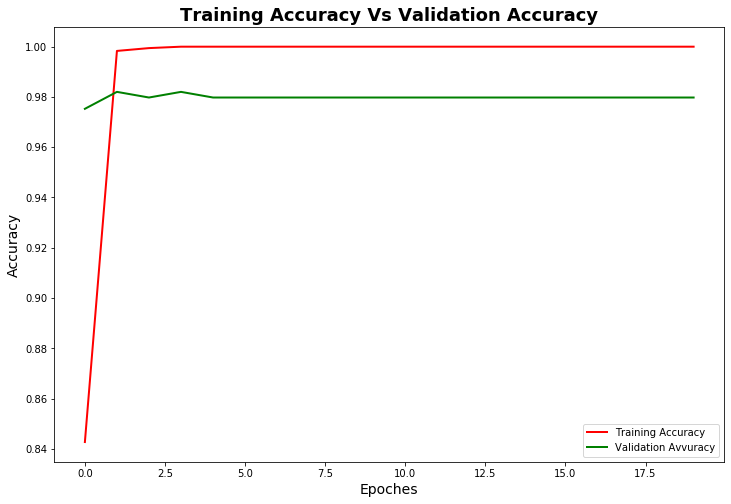

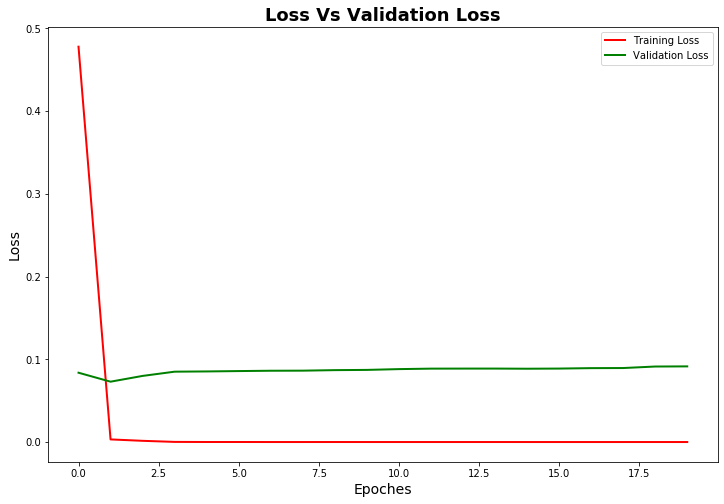

In [107]:
import matplotlib.pyplot as plt
plt.figure(figsize=[12,8])
plt.plot(history.history['accuracy'],'r',linewidth = 2.0)
plt.plot(history.history['val_accuracy'],'g',linewidth = 2.0)
plt.legend(['Training Accuracy','Validation Avvuracy'])
plt.xlabel("Epoches",fontsize=14)
plt.ylabel("Accuracy",fontsize=14)
plt.title("Training Accuracy Vs Validation Accuracy",fontweight = 'bold',fontsize=18)

plt.figure(figsize=[12,8])
plt.plot(history.history['loss'],'r',linewidth=2.0)
plt.plot(history.history['val_loss'],'g',linewidth = 2.0)
plt.legend(['Training Loss','Validation Loss'])
plt.xlabel("Epoches",fontsize=14)
plt.ylabel("Loss",fontsize=14)
plt.title("Loss Vs Validation Loss",fontweight = 'bold',fontsize=18)

# Confusion Matrix

In [114]:
from sklearn.metrics import confusion_matrix,plot_confusion_matrix,classification_report
y_pred = model.predict_classes(X_test,verbose=0)
y_pred2 = np.argmax(Y_test,axis = -1)
reasult = confusion_matrix(y_pred2,y_pred)
print("=======================================")
print("Confusion Matrix")
print("=======================================")
print(reasult)
print("=======================================")
print("Classificaiton Report")
print("=======================================")
print(classification_report(y_pred2,y_pred,target_names=news_categories))

Confusion Matrix
[[102   1   3   0   0]
 [  0  64   1   0   1]
 [  1   1  83   0   1]
 [  0   0   0 101   0]
 [  0   0   0   0  86]]
Classificaiton Report
               precision    recall  f1-score   support

     politics       0.99      0.96      0.98       106
        sport       0.97      0.97      0.97        66
entertainment       0.95      0.97      0.96        86
     business       1.00      1.00      1.00       101
         tech       0.98      1.00      0.99        86

     accuracy                           0.98       445
    macro avg       0.98      0.98      0.98       445
 weighted avg       0.98      0.98      0.98       445



Text(0.5, 1, 'Confusion Matrix Visualization with Seaborn')

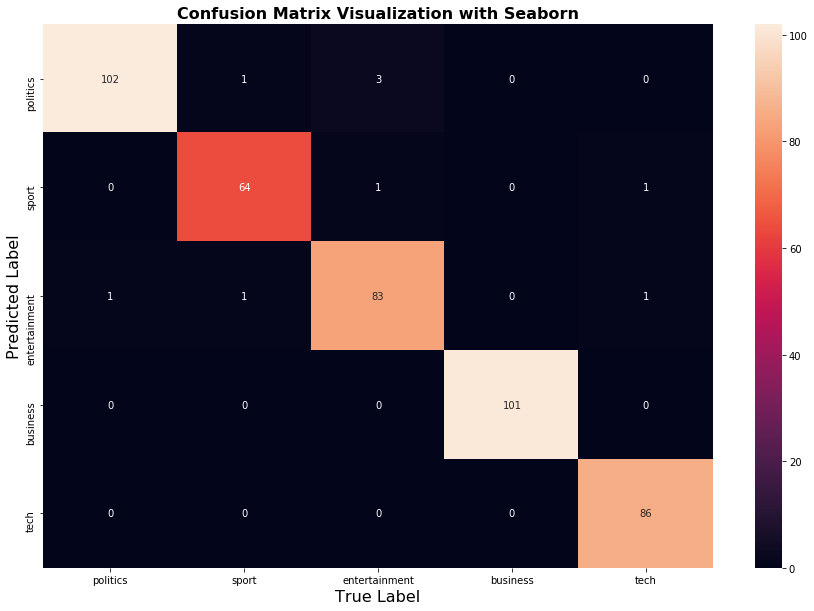

In [119]:
import seaborn as sns
figure_size = plt.figure(figsize=(15,10))
x_tick_label = ['politics','sport','entertainment','business','tech']
y_tick_label = ['politics','sport','entertainment','business','tech']
heatmap = sns.heatmap(reasult,annot=True,fmt='d',xticklabels=x_tick_label,yticklabels=y_tick_label)
plt.xlabel("True Label",fontsize = 16)
plt.ylabel("Predicted Label",fontsize = 16)
plt.title("Confusion Matrix Visualization with Seaborn",fontsize = 16,fontweight = 'bold')

In [120]:
## Saving the Model
model.save("Bbc_Csv_TextClassifier.h5")

# Testing Model on Inputs

In [123]:
text_labels = encoder.classes_
for i in range(10):
  prediction = model.predict(np.array([X_test[i]]))
  predicted_class = text_labels[np.argmax(prediction[0])]
  print(test_data_text.iloc[i])
  print('Actual Category =',test_data_category.iloc[i])
  print('Predicted Category =',predicted_class)

hobbit picture  four years away  lord of the rings director peter jackson has said that it will be up to four years before he starts work on a film version of the hobbit.  the oscar winner said on a visit to sydney there was a  desire  to make it  but not before lengthy negotiations.  i think it s gonna be a lot of lawyers sitting in a room trying to thrash out a deal before it will ever happen   said the new zealander. the rights to jrr tolkien s book are split between two major film studios. jackson  who is currently filming a remake of hollywood classic king kong  said he thought that the sale of mgm studios to the sony corporation would cast further uncertainty on the project. the 43-year-old was in the australian city to visit a lord of the rings exhibition  which has attracted 140 000 visitors since it opened in december.  the film-maker recently sued film company new line cinema for undisclosed damages over alleged withheld profits and lost revenue from the first part of the mid

ultimate game  award for doom 3 sci-fi shooter doom 3 has blasted away the competition at a major games ceremony  the golden joystick awards.  it was the only title to win twice  winning ultimate game of the year and best pc game at the awards  presented by little britain star matt lucas. the much-anticipated sci-fi horror doom 3 shot straight to the top of the uk games charts on its release in august. other winners included grand theft auto: san andreas which took the most wanted for christmas prize. only released last week  it was closely followed by halo 2 and half-life 2  which are expected to be big hits when they are unleashed later this month.  but they missed out on the prize for the most wanted game of 2005  which went to the nintendo title  the legend of zelda. the original doom  released in 1994  heralded a new era in computer games and introduced 3d graphics. it helped to establish the concept of the first-person shooter. doom 3 was developed over four years and is thought 

In [125]:
import pickle
with open('tokenizer.pickle','wb') as myfile:
  pickle.dump(tokenizer,myfile,protocol=pickle.HIGHEST_PROTOCOL)

In [126]:
from keras.models import load_model
model = load_model('Bbc_Csv_TextClassifier.h5')
tokenizer = Tokenizer()
with open('tokenizer.pickle','rb') as myfile:
  tokenizer = pickle.load(myfile)

labels = encoder.classes_
labels

array(['business', 'entertainment', 'politics', 'sport', 'tech'],
      dtype='<U13')

In [128]:
test_files = "news.txt"
b = open(test_files,'r')
data = b.read()
data_series = pd.Series(data)
data_tokenized = tokenizer.texts_to_matrix(data_series,mode='tfidf')
prediction = model.predict(data_tokenized)
predicted_class = text_labels[np.argmax(prediction[0])]
print('My News =',data)
print('Predicted Category =',predicted_class)
print('My category = ',labels)
print('Prediction Value = ',prediction)

FileNotFoundError: [Errno 2] No such file or directory: 'news.txt'